# Ejercicio 01
# Agrupamiento de alertas de un SIEM con K-means

Trabajo en clase

Msc. William Rodríguez Calvo

Semana 10, Aprendizaje no supervisado

## Para qué sirve este ejercicio

El objetivo es que el grupo recorra un proyecto completo de agrupamiento
(clustering) desde datos sin etiqueta hasta grupos interpretables, y
compruebe en la práctica por qué el aprendizaje no supervisado es útil
cuando no existen ejemplos previos de un comportamiento.

## ¿Qué simula?

El archivo de datos representa 600 alertas generadas por un SIEM. En la vida
real esas alertas nunca llegan con una etiqueta que diga a qué tipo de
comportamiento corresponden, aquí se simulan cuatro perfiles distintos, ruido
normal, escaneo de puertos, fuerza bruta y exfiltración, para poder
comprobar al final si el algoritmo logró descubrirlos sin ayuda.

## ¿Cómo se conecta con la ciberseguridad?

Un centro de operaciones de seguridad puede recibir miles de alertas
diarias, muchas de ellas variaciones del mismo problema generadas por el
mismo sensor. Agrupar esas alertas en familias permite que un analista
revise una familia completa en lugar de alerta por alerta, lo que reduce
directamente la fatiga de alertas, uno de los problemas operativos más
citados en los equipos de seguridad.

## Datos

El archivo `datos/alertas_siem.csv` contiene las siguientes columnas.

- `alerta_id`, identificador de la alerta.
- `num_eventos`, cantidad de eventos individuales agrupados en la alerta.
- `duracion_promedio_seg`, duración promedio de los eventos en segundos.
- `distintos_puertos`, cantidad de puertos distintos involucrados.
- `distintos_ips_origen`, cantidad de direcciones IP de origen distintas.
- `hora_del_dia`, hora en que se concentró la actividad, de 0 a 23.
- `perfil_real`, el perfil verdadero que generó la alerta. Esta columna es la
  respuesta correcta y solo debe usarse al final, para calificar los grupos
  encontrados, nunca para entrenar el modelo.


## Paso 1
## Cargar y explorar los datos

Objetivo de este paso, leer el archivo CSV y confirmar que los datos se
cargaron correctamente antes de hacer cualquier análisis. `df.shape`
indica cuántas alertas (filas) y variables (columnas) tiene el conjunto de
datos, y `df.head()` muestra las primeras filas para verificar que cada
columna contiene lo esperado antes de seguir adelante.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("datos/alertas_siem.csv")
print(df.shape)
df.head()


(600, 7)


,alerta_id,num_eventos,duracion_promedio_seg,distintos_puertos,distintos_ips_origen,hora_del_dia,perfil_real
0,1,9,46.68,2,3,13,ruido_normal
1,2,174,6.74,0,1,5,fuerza_bruta
2,3,24,876.32,7,1,4,exfiltracion
3,4,6,45.28,3,1,7,ruido_normal
4,5,424,1.77,129,2,0,escaneo_puertos


**Objetivo de `df.describe()`.** Antes de entrenar cualquier modelo
conviene revisar las estadísticas descriptivas de cada variable numérica,
para detectar dos cosas concretas: variables que están en escalas muy
distintas entre sí, lo que justificará el escalado del paso 2, y valores
extremos que podrían ser errores de carga de datos en lugar de
comportamiento real. Las columnas de esta tabla significan lo siguiente.

- `count`, cantidad de valores no nulos de esa variable.
- `mean` y `std`, el promedio y la desviación estándar, es decir, el valor
  típico de la variable y qué tan dispersos están los datos alrededor de
  ese promedio.
- `min` y `max`, los valores más bajo y más alto observados.
- `25%`, `50%` y `75%`, los percentiles, donde `50%` es la mediana. Si
  `mean` y `50%` difieren mucho, la variable tiene una distribución
  asimétrica, con algunos valores altos que arrastran el promedio.

In [2]:
df.describe()


,alerta_id,num_eventos,duracion_promedio_seg,distintos_puertos,distintos_ips_origen,hora_del_dia
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,300.500000,120.218333,168.309317,45.763333,1.986667,9.046667
std,173.349358,123.256024,276.462016,78.051141,1.272473,8.219718
min,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,150.750000,12.000000,2.997500,1.000000,1.000000,2.000000
50%,300.500000,52.500000,11.415000,3.000000,2.000000,5.000000
75%,450.250000,194.000000,119.712500,21.500000,3.000000,16.000000
max,600.000000,439.000000,1015.120000,292.000000,9.000000,23.000000


## Paso 2
## Preparar y escalar los datos

Objetivo de este paso, dejar todas las variables en una escala comparable
antes de entrenar. K-means depende de la distancia euclidiana entre
puntos, y una variable con valores mucho más grandes que las demás (por
ejemplo `num_eventos` frente a `hora_del_dia`) dominaría esa distancia por
su magnitud, no porque sea más importante. Se retiran `alerta_id` y
`perfil_real` del conjunto de entrenamiento, la primera por ser solo un
identificador y la segunda porque es la respuesta correcta que no debe
usarse para entrenar un modelo no supervisado.

In [3]:
features = ["num_eventos", "duracion_promedio_seg", "distintos_puertos",
            "distintos_ips_origen", "hora_del_dia"]

X = df[features].copy()
scaler = StandardScaler()
X_esc = scaler.fit_transform(X)
X_esc[:5]


array([[-0.90308877, -0.44031655, -0.56116859,  0.79701403,  0.4813586 ],
       [ 0.43670515, -0.5849054 , -0.58681419, -0.77603998, -0.49272289],
       [-0.78128932,  2.56310592, -0.49705457, -0.77603998, -0.61448307],
       [-0.92744866, -0.44538476, -0.54834578, -0.77603998, -0.24920251],
       [ 2.46669595, -0.60289755,  1.06732735,  0.01048703, -1.10152382]])

Después del escalado, cada variable tiene promedio 0 y desviación
estándar 1, por lo que los valores que se ven arriba ya no están en las
unidades originales (segundos, cantidad de puertos, etc.), sino expresados
en cuántas desviaciones estándar se alejan del promedio. Un valor de 0
significa que esa observación está en el promedio de esa variable, un
valor de 2 significa que está dos desviaciones estándar por encima.

## Paso 3
## Elegir el número de grupos K

Objetivo de este paso, encontrar un valor de K razonable en lugar de
elegirlo de forma arbitraria. Se calcula la inercia (método del codo) y el
coeficiente de silueta para valores de K entre 2 y 8.

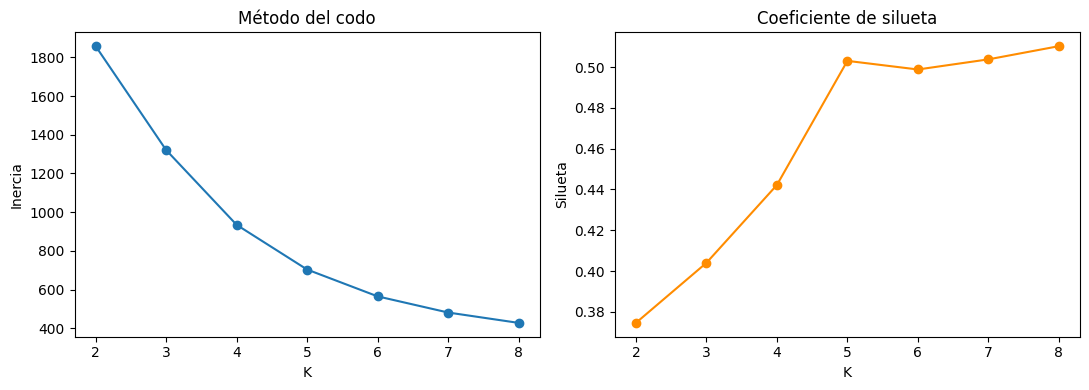

K=2  silueta=0.375
K=3  silueta=0.404
K=4  silueta=0.442
K=5  silueta=0.503
K=6  silueta=0.499
K=7  silueta=0.504
K=8  silueta=0.510


In [4]:
inercias = []
siluetas = []
valores_k = range(2, 9)

for k in valores_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo.fit_predict(X_esc)
    inercias.append(modelo.inertia_)
    siluetas.append(silhouette_score(X_esc, etiquetas))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(list(valores_k), inercias, marker="o")
ax[0].set_title("Método del codo")
ax[0].set_xlabel("K")
ax[0].set_ylabel("Inercia")

ax[1].plot(list(valores_k), siluetas, marker="o", color="darkorange")
ax[1].set_title("Coeficiente de silueta")
ax[1].set_xlabel("K")
ax[1].set_ylabel("Silueta")
plt.tight_layout()
plt.show()

for k, s in zip(valores_k, siluetas):
    print(f"K={k}  silueta={s:.3f}")


**Cómo interpretar estas dos gráficas.** El método del codo grafica
la inercia, que mide qué tan compactos son los grupos, contra cada valor
de K. La inercia siempre baja al aumentar K, lo que se busca es el punto
donde deja de bajar de forma pronunciada y la curva forma un codo, porque
agregar más grupos después de ese punto ya no compacta mucho más los
datos. El coeficiente de silueta va de -1 a 1 y combina dos ideas, qué tan
cerca está cada punto de los demás puntos de su propio grupo y qué tan
lejos está de los otros grupos, valores cercanos a 1 indican grupos bien
separados y valores cercanos a 0 o negativos indican grupos que se
mezclan entre sí. No existe una única respuesta correcta, el objetivo es
usar ambas gráficas como evidencia para justificar el valor de K elegido
en el paso siguiente.

## Paso 4
## Entrenar el modelo final

Objetivo de este paso, entrenar el modelo definitivo con un valor de K
concreto y revisar cuántas alertas cayeron en cada grupo. Se conocen
cuatro perfiles de origen en este ejercicio. Entrenen K-means con el valor
de K que consideren más razonable según el paso anterior y comparen
contra K=4.

In [5]:
K_ELEGIDO = 4  # ajusten este valor según su análisis del paso 3

modelo_final = KMeans(n_clusters=K_ELEGIDO, random_state=42, n_init=10)
df["cluster"] = modelo_final.fit_predict(X_esc)
df["cluster"].value_counts().sort_index()


cluster
0     82
1    222
2    150
3    146
Name: count, dtype: int64

Esta tabla muestra cuántas alertas quedaron asignadas a cada número
de cluster. Grupos de tamaño muy desigual no son necesariamente un error,
pero conviene fijarse en ellos, un grupo con muy pocas alertas podría
representar un comportamiento raro que vale la pena revisar de cerca, y un
grupo enorme podría estar mezclando comportamientos distintos que un
valor de K más alto separaría mejor.

## Paso 5
## Interpretar los grupos

Objetivo de este paso, darle significado a cada número de cluster
calculando el promedio de cada variable dentro de ese grupo, y solo al
final comparar contra el perfil real conocido para calificar el
resultado.

In [6]:
resumen = df.groupby("cluster")[features].mean().round(1)
resumen


,num_eventos,duracion_promedio_seg,distintos_puertos,distintos_ips_origen,hora_del_dia
cluster,,,,,
0,142.3,5.4,1.1,4.3,4.3
1,51.2,34.2,1.8,1.4,10.3
2,304.1,2.1,176.6,2.2,5.8
3,23.8,634.6,3.3,1.4,13.1


Esta tabla resume el perfil típico de cada cluster, el promedio de
cada variable para las alertas que quedaron en ese grupo. Comparar una
fila contra otra permite describir cada grupo en palabras, por ejemplo un
cluster con `distintos_puertos` muy alto y `duracion_promedio_seg` baja
sugiere un patrón de escaneo, mientras uno con `distintos_ips_origen` muy
alto sugiere un patrón de fuerza bruta o de un ataque coordinado desde
muchos orígenes.

In [7]:
# Solo ahora se usa perfil_real, únicamente para validar el resultado
tabla_cruzada = pd.crosstab(df["cluster"], df["perfil_real"])
tabla_cruzada


perfil_real,escaneo_puertos,exfiltracion,fuerza_bruta,ruido_normal
cluster,,,,
0,0,0,80,2
1,0,4,70,148
2,150,0,0,0
3,0,146,0,0


**Cómo leer la tabla cruzada.** Cada fila es un cluster encontrado
por el algoritmo y cada columna es un perfil real conocido de antemano.
Si el agrupamiento funcionó bien, cada fila debería concentrar casi todas
sus alertas en una sola columna, es decir, cada cluster corresponde
mayormente a un solo perfil real. Si una fila reparte sus alertas entre
varias columnas, ese cluster está mezclando comportamientos distintos que
el modelo no logró separar. Recuerden que esta comparación solo es
posible aquí porque se trata de un ejercicio de clase con datos
simulados, en un caso real casi nunca se cuenta con esta etiqueta de
verificación.

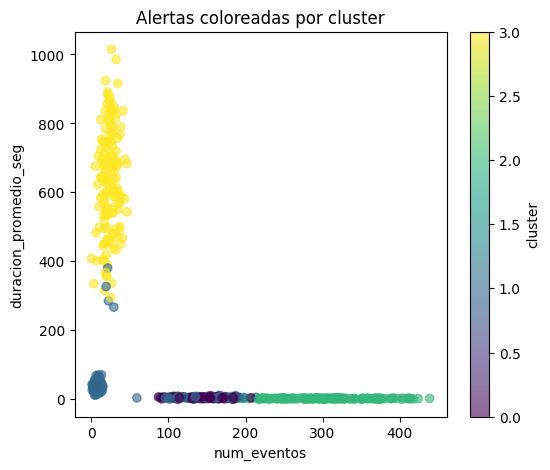

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
dispersion = ax.scatter(df["num_eventos"], df["duracion_promedio_seg"],
                         c=df["cluster"], cmap="viridis", alpha=0.6)
ax.set_xlabel("num_eventos")
ax.set_ylabel("duracion_promedio_seg")
ax.set_title("Alertas coloreadas por cluster")
plt.colorbar(dispersion, label="cluster")
plt.show()


Este gráfico proyecta solo dos de las cinco variables usadas para
entrenar el modelo, por lo que dos alertas pueden verse cerca en esta
imagen y en realidad pertenecer a clusters distintos por diferencias en
las otras tres variables. Sirve como una revisión visual rápida, no como
prueba definitiva de que los grupos están bien formados, para eso se usa
el coeficiente de silueta y la tabla cruzada del paso anterior.

## Preguntas de análisis

1. Al revisar la tabla cruzada contra `perfil_real`, ¿Qué clúster
   corresponde a cada perfil y qué tan limpia es la separación encontrada?
3. ¿Qué variable parece dominar la formación de los grupos y por qué tendría
   sentido eso en un entorno real de un SOC?
4. Si un analista solo pudiera revisar un grupo hoy por falta de tiempo,
   ¿Cuál elegirían primero y por qué?